# Preprocessing

In [1]:

from pathlib import Path


import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torchvision import transforms

In [2]:
DATA_DIR = Path("../data/raw/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])

print("Classes:")
print(class_names)

train_paths = sorted(list(TRAIN_DIR.glob("*/*.jpg")))
val_paths = sorted(list(VAL_DIR.glob("*/*.jpg")))
test_paths = sorted(list(TEST_DIR.glob("*/*.jpg")))

print(f"Train images: {len(train_paths)}")
print(f"Val images:   {len(val_paths)}")
print(f"Test images:  {len(test_paths)}")

Classes:
['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']
Train images: 18400
Val images:   2800
Test images:  2800


In [3]:
TARGET_SIZE = (256, 128)  # width, height

def preprocess_image(path, target_size=TARGET_SIZE):
    img = Image.open(path).convert("L")
    img = img.resize(target_size, resample=Image.BILINEAR)
    
    arr = np.array(img).astype(np.float32)
    arr = arr / 255.0
    
    return arr

Processed shape: (128, 256)
Dtype: float32
Min: 0.14509805
Max: 0.93333334


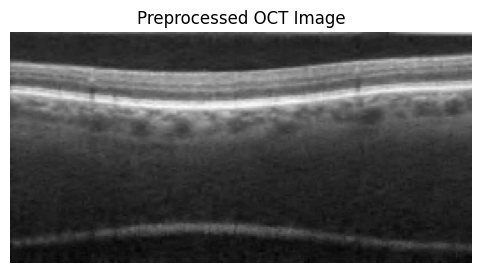

In [4]:
sample_path = train_paths[0]

processed = preprocess_image(sample_path)

print("Processed shape:", processed.shape)
print("Dtype:", processed.dtype)
print("Min:", processed.min())
print("Max:", processed.max())

plt.figure(figsize=(6, 3))
plt.imshow(processed, cmap="gray")
plt.axis("off")
plt.title("Preprocessed OCT Image")
plt.show()

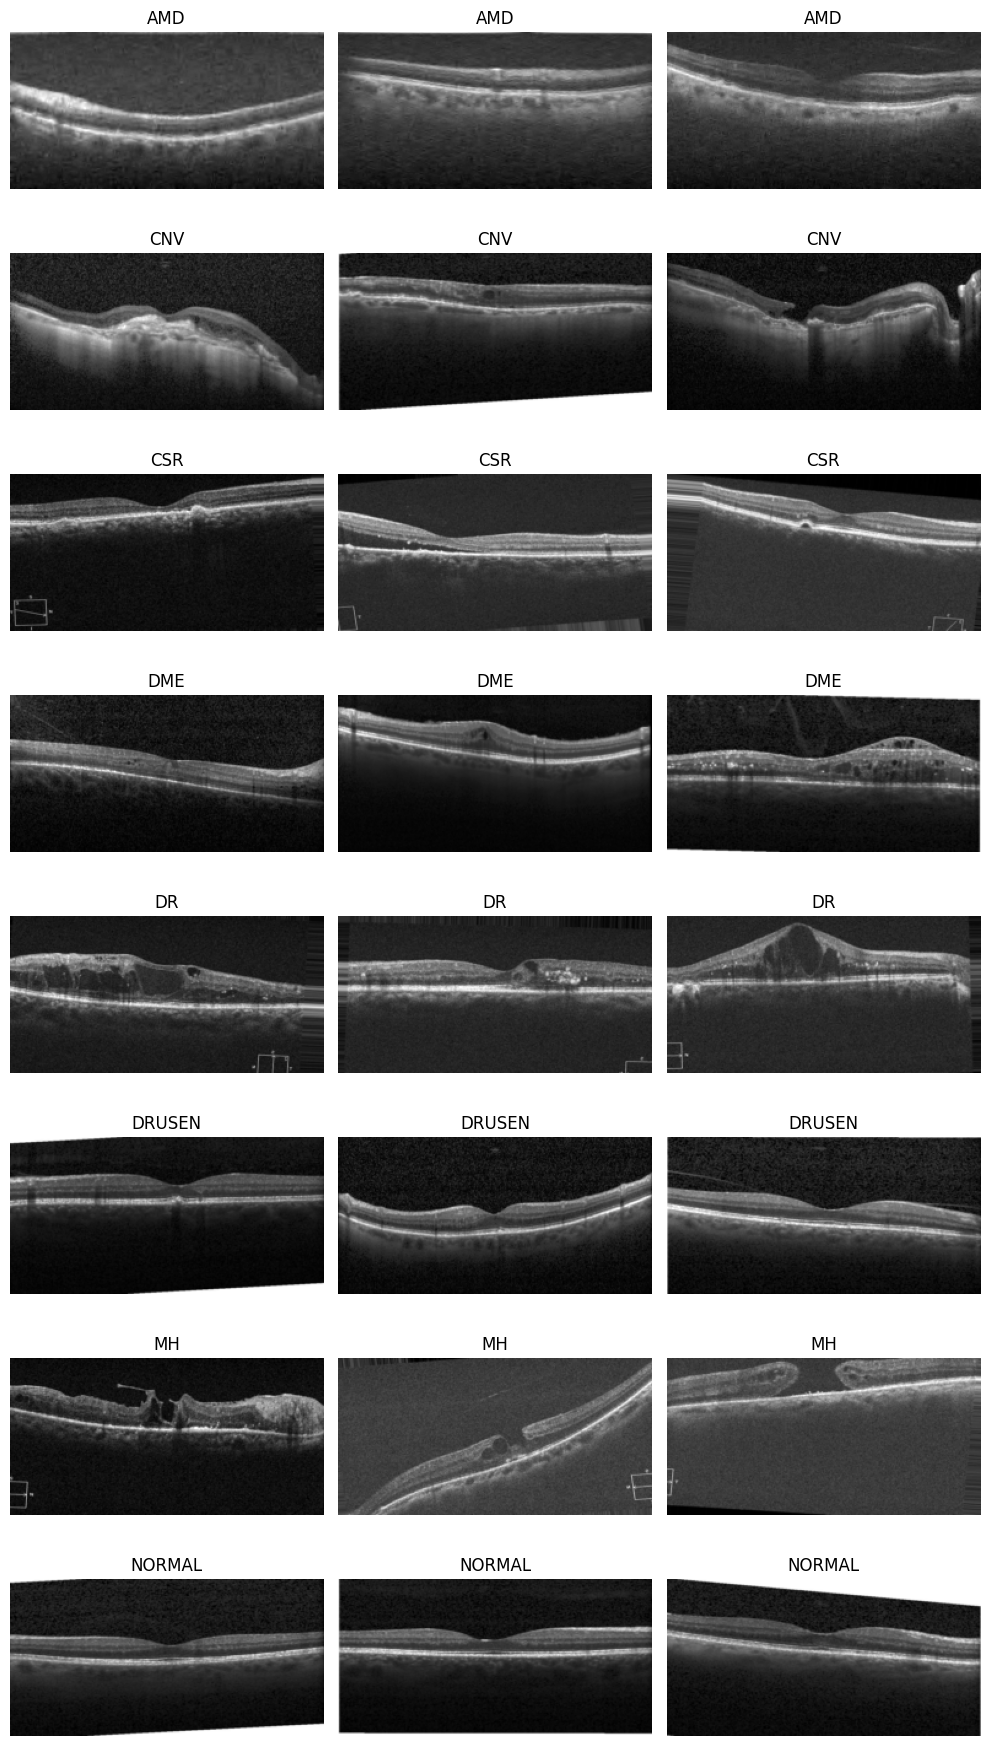

In [5]:
import random

fig, axes = plt.subplots(len(class_names), 3, figsize=(10, 18))

for row, cls in enumerate(class_names):
    cls_paths = sorted(list((TRAIN_DIR / cls).glob("*.jpg")))
    sample_paths = random.sample(cls_paths, 3)
    
    for col, path in enumerate(sample_paths):
        img = preprocess_image(path)
        
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Create simple mask generators

def center_mask(shape, mask_size=(64, 64)):
    
    h, w = shape
    
    mask = np.ones((h, w), dtype=np.float32)
    
    mh, mw = mask_size
    
    top = (h - mh) // 2
    left = (w - mw) // 2
    
    mask[top:top+mh, left:left+mw] = 0.0
    
    return mask


def horizontal_stripe_mask(shape, stripe_height=24):
    
    h, w = shape
    
    mask = np.ones((h, w), dtype=np.float32)
    
    center = h // 2
    
    top = center - stripe_height // 2
    
    mask[top:top+stripe_height, :] = 0.0
    
    return mask


def random_square_mask(shape, square_size=48):
    
    h, w = shape
    
    mask = np.ones((h, w), dtype=np.float32)
    
    top = np.random.randint(0, h - square_size)
    left = np.random.randint(0, w - square_size)
    
    mask[top:top+square_size, left:left+square_size] = 0.0
    
    return mask

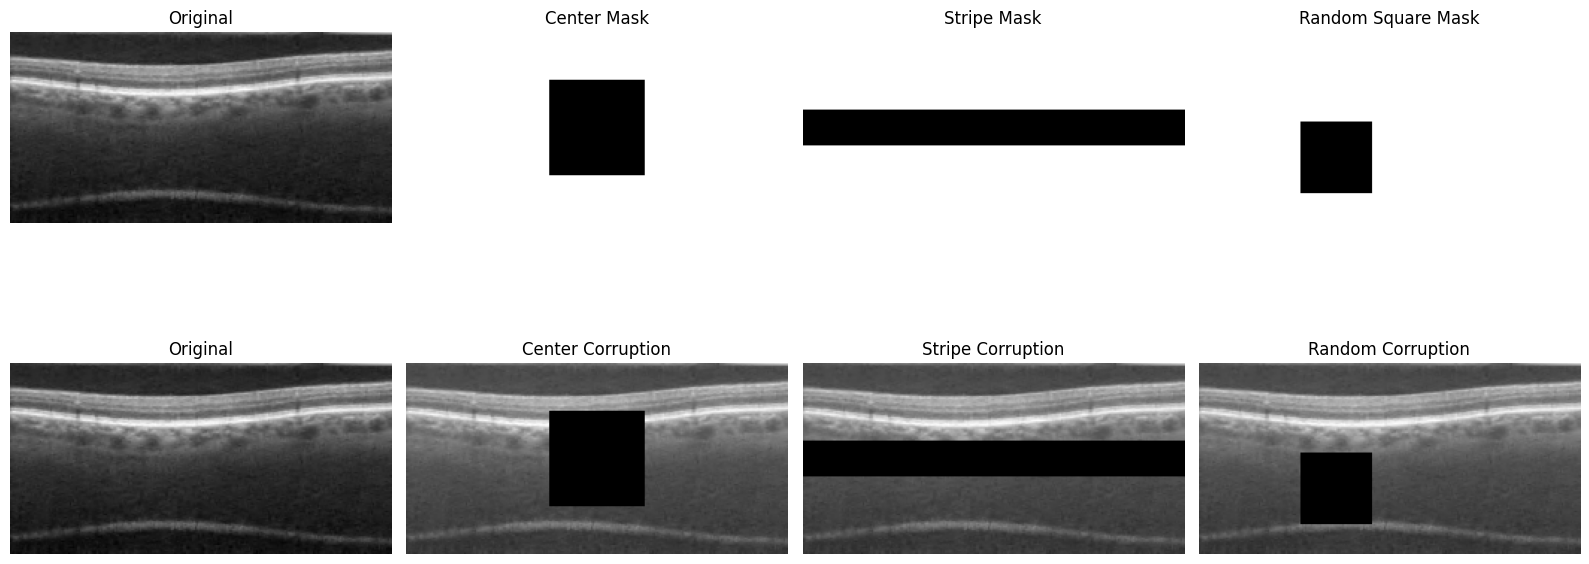

In [7]:
# Visualize masking strategies

sample_img = preprocess_image(train_paths[0])

center = center_mask(sample_img.shape)
stripe = horizontal_stripe_mask(sample_img.shape)
random_mask = random_square_mask(sample_img.shape)

masked_center = sample_img * center
masked_stripe = sample_img * stripe
masked_random = sample_img * random_mask

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Row 1: masks

axes[0, 0].imshow(sample_img, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(center, cmap="gray")
axes[0, 1].set_title("Center Mask")
axes[0, 1].axis("off")

axes[0, 2].imshow(stripe, cmap="gray")
axes[0, 2].set_title("Stripe Mask")
axes[0, 2].axis("off")

axes[0, 3].imshow(random_mask, cmap="gray")
axes[0, 3].set_title("Random Square Mask")
axes[0, 3].axis("off")

# Row 2: masked images

axes[1, 0].imshow(sample_img, cmap="gray")
axes[1, 0].set_title("Original")
axes[1, 0].axis("off")

axes[1, 1].imshow(masked_center, cmap="gray")
axes[1, 1].set_title("Center Corruption")
axes[1, 1].axis("off")

axes[1, 2].imshow(masked_stripe, cmap="gray")
axes[1, 2].set_title("Stripe Corruption")
axes[1, 2].axis("off")

axes[1, 3].imshow(masked_random, cmap="gray")
axes[1, 3].set_title("Random Corruption")
axes[1, 3].axis("off")

plt.tight_layout()
plt.show()

In [8]:
# PyTorch dataset for OCT inpainting

from torch.utils.data import Dataset

class OCTInpaintingDataset(Dataset):
    
    def __init__(
        self,
        image_paths,
        preprocess_fn,
        mask_fn
    ):
        self.image_paths = image_paths
        self.preprocess_fn = preprocess_fn
        self.mask_fn = mask_fn
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        
        path = self.image_paths[idx]
        
        # Preprocess image
        img = self.preprocess_fn(path)
        
        # Generate mask
        mask = self.mask_fn(img.shape)
        
        # Corrupted image
        masked_img = img * mask
        
        # Convert to tensors
        img = torch.tensor(img).unsqueeze(0).float()
        mask = torch.tensor(mask).unsqueeze(0).float()
        masked_img = torch.tensor(masked_img).unsqueeze(0).float()
        
        return {
            "image": img,
            "mask": mask,
            "masked_image": masked_img
        }

Image: torch.Size([1, 128, 256])
Mask: torch.Size([1, 128, 256])
Masked image: torch.Size([1, 128, 256])


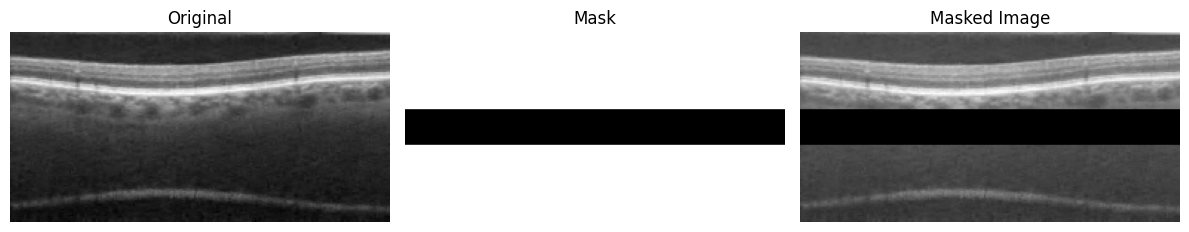

In [9]:
stripe_dataset = OCTInpaintingDataset(
    image_paths=train_paths,
    preprocess_fn=preprocess_image,
    mask_fn=horizontal_stripe_mask
)

sample = stripe_dataset[0]

print("Image:", sample["image"].shape)
print("Mask:", sample["mask"].shape)
print("Masked image:", sample["masked_image"].shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sample["image"].squeeze(), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(sample["mask"].squeeze(), cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")

axes[2].imshow(sample["masked_image"].squeeze(), cmap="gray")
axes[2].set_title("Masked Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    stripe_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

batch = next(iter(train_loader))

print("Image batch:", batch["image"].shape)
print("Mask batch:", batch["mask"].shape)
print("Masked image batch:", batch["masked_image"].shape)

Image batch: torch.Size([8, 1, 128, 256])
Mask batch: torch.Size([8, 1, 128, 256])
Masked image batch: torch.Size([8, 1, 128, 256])


# Experimental Journal — 01 Preprocessing

## Objective

The goal of this notebook was to construct the first standardized preprocessing and corruption pipeline for OCT inpainting experiments.

This notebook established:
- image preprocessing procedures,
- masking/corruption strategies,
- PyTorch dataset construction,
- and diffusion-ready dataloading infrastructure.

The preprocessing pipeline serves as the foundation for all later:
- PDE reconstruction,
- classical inpainting,
- and DDPM experiments.

---

# Dataset Loading and Organization

The notebook begins by:
- loading the retinal OCT dataset,
- defining train/validation/test splits,
- and enumerating all disease classes.

The dataset contains 8 classes:
- AMD
- CNV
- CSR
- DME
- DR
- DRUSEN
- MH
- NORMAL

The following dataset sizes were confirmed:
- Train: 18,400 images
- Validation: 2,800 images
- Test: 2,800 images

This establishes a sufficiently large dataset for:
- reconstruction experiments,
- generative modeling,
- and corruption-based learning tasks.

---

# Core Preprocessing Pipeline

The preprocessing pipeline was intentionally designed to remain simple and conservative.

The implemented steps were:

1. image loading,
2. grayscale conversion,
3. resizing,
4. intensity normalization.

---

# Step 1 — Grayscale Conversion

Images were converted using:

```python
Image.open(path).convert("L")
```

This was important because:
- the dataset is effectively grayscale,
- RGB channels contain redundant information,
- and single-channel inputs reduce computational cost.

Benefits:
- lower memory usage,
- simpler convolutional architectures,
- more stable diffusion training,
- faster experimentation.

---

# Step 2 — Resizing

Images were resized to:

```python
(256, 128)
```

using bilinear interpolation.

This resolution was selected because:
- it preserves retinal layer geometry reasonably well,
- maintains horizontal anatomical structure,
- and significantly reduces computational requirements.

A major design consideration was preserving:
- aspect ratio,
- retinal continuity,
- and disease morphology.

Aggressive square resizing was intentionally avoided because it could distort:
- retinal curvature,
- fluid pockets,
- and pathological structures.

---

# Step 3 — Intensity Normalization

Pixel intensities were normalized to:

```python
[0, 1]
```

via division by `255.0`.

This normalization step is important because it:
- stabilizes optimization,
- prevents exploding activations,
- standardizes reconstruction targets,
- and improves numerical stability in diffusion models.

The resulting processed images had:
- shape `(128, 256)`,
- dtype `float32`,
- and bounded intensity ranges.

---

# Verification of Preprocessing

Processed sample images were visualized across all disease classes.

Important observations:

## Anatomical Structure Preservation

Even after resizing:
- retinal layers remained visually coherent,
- disease morphology was still recognizable,
- and pathological structures remained visible.

This validated the selected preprocessing resolution.

---

## Noise Retention

Speckle noise and scanner artifacts remained present.

This was intentional.

The pipeline avoided aggressive denoising because:
- OCT speckle is part of the true imaging distribution,
- removing it prematurely may simplify reconstruction artificially,
- and diffusion models should learn realistic OCT statistics.

---

## Morphological Diversity

Visual inspection confirmed substantial anatomical diversity across diseases:
- edema,
- retinal detachments,
- macular holes,
- drusen,
- and fluid accumulations.

This implies:
- reconstruction difficulty will vary substantially across samples,
- especially in pathological regions.

---

# Corruption and Masking Strategies

A major goal of this notebook was designing corruption strategies for inpainting tasks.

Three masking methods were implemented:

1. center masks,
2. horizontal stripe masks,
3. random square masks.

Each corruption type targets a different reconstruction challenge.

---

# Center Mask

The center mask removes a localized square region from the image.

Purpose:
- tests localized semantic reconstruction,
- evaluates ability to infer missing retinal structures,
- resembles traditional image inpainting benchmarks.

This corruption primarily tests:
- local anatomical consistency,
- and semantic continuity.

---

# Random Square Mask

The random square mask removes a randomly positioned patch.

Purpose:
- tests texture continuity,
- evaluates robustness to arbitrary corruption,
- introduces spatial variability.

This corruption helps determine whether models can:
- generalize reconstruction behavior,
- and recover missing local structure in different spatial locations.

---

# Horizontal Stripe Mask

The horizontal stripe mask removes a full-width retinal band.

This became the most important corruption strategy.

Why it matters:

Retinal OCT anatomy is highly horizontally structured.

A stripe corruption forces models to:
- reconstruct long-range retinal continuity,
- infer anatomical layer progression,
- and recover structure using global contextual information.

This corruption is substantially harder than local patch reconstruction.

It also closely resembles:
- acquisition corruption,
- missing scan regions,
- or partial OCT failure.

The stripe mask later became the primary corruption strategy for:
- PDE reconstruction,
- Telea inpainting,
- and DDPM experiments.

---

# Corruption Visualization

Masks and corrupted images were visualized directly.

Important observations:

## Center Corruption
- relatively localized,
- much of the retinal context remains available.

## Random Corruption
- highly variable,
- tests local consistency.

## Stripe Corruption
- removes critical anatomical continuity,
- creates a true inverse reconstruction problem.

The stripe corruption was visually and conceptually the most challenging corruption type.

---

# PyTorch Dataset Construction

A custom PyTorch dataset class was implemented:

```python
OCTInpaintingDataset
```

The dataset performs:
- preprocessing,
- mask generation,
- corruption generation,
- and tensor conversion on-the-fly.

Each dataset sample returns:
- original image,
- mask,
- corrupted image.

This structure is ideal for:
- supervised reconstruction,
- conditional diffusion,
- and masked inverse-problem learning.

---

# Tensor Formatting

All images were converted to tensors with shape:

```python
[1, 128, 256]
```

representing:
- single grayscale channel,
- height,
- width.

This standardized tensor format is critical for:
- CNN compatibility,
- batch loading,
- and diffusion model training.

---

# DataLoader Construction

A PyTorch `DataLoader` was created with:
- batch size 8,
- random shuffling,
- batched image/mask loading.

The resulting batch shapes were:

```python
[8, 1, 128, 256]
```

for:
- original images,
- masks,
- and corrupted images.

This verified that the preprocessing pipeline integrates correctly with PyTorch training workflows.

---

# Key Experimental Takeaways

## Preprocessing Insights

- Conservative preprocessing preserves retinal anatomy well.
- Grayscale conversion simplifies modeling.
- Moderate downsampling retains important pathology.
- Noise preservation may improve realism in generative training.

---

## Corruption Insights

- Local corruption is relatively easy.
- Stripe corruption creates a substantially harder reconstruction problem.
- Retinal OCT reconstruction is fundamentally directional and continuity-based.

---

## Dataset Engineering Insights

The custom dataset abstraction successfully:
- standardizes preprocessing,
- automates corruption generation,
- and creates diffusion-ready training samples.

This notebook established the infrastructure required for:
- classical inpainting baselines,
- PDE reconstruction,
- and conditional DDPM training.

---

# Limitations Observed

Several limitations became apparent:

- resizing may still remove fine pathological detail,
- stripe masks may oversimplify real corruption patterns,
- preprocessing currently ignores retinal layer segmentation,
- no explicit denoising or artifact correction is applied,
- corruption remains synthetic rather than acquisition-derived.

These limitations may influence:
- reconstruction realism,
- generative uncertainty,
- and downstream evaluation.

---

# Future TODOs

- implement PDE-based reconstruction baselines,
- benchmark classical inpainting algorithms,
- test reconstruction quality across corruption types,
- experiment with adaptive or pathology-aware masks,
- prepare conditional datasets for DDPM training.